<a href="https://colab.research.google.com/github/MiyoBran/alura-etl-telecom-x/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

Para iniciar tu análisis, necesitarás importar los datos de la API de **Telecom X**. Estos datos están disponibles en formato **JSON** y contienen información esencial sobre los clientes, incluyendo datos demográficos, tipo de servicio contratado y estado de evasión.

📌 **Enlace de la API:**
🔗 [https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json](https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json "smartCard-inline")

🔗[https://github.com/ingridcristh/challenge2-data-science-LATAM](https://github.com/ingridcristh/challenge2-data-science-LATAM "smartCard-inline")

### ¿Qué debes hacer?

✅ Cargar los datos directamente desde la API utilizando **Python**.
✅ Convertir los datos a un **DataFrame de Pandas** para facilitar su manipulación.

Este es el primer paso para transformar los datos en información valiosa. ¿Listo para programar? 🚀

In [37]:
import pandas as pd

url='https://raw.githubusercontent.com/MiyoBran/alura-etl-telecom-x/main/TelecomX_Data.json'
df = pd.read_json(url)
display(df.head())

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


Ahora que has extraído los datos, es fundamental comprender la estructura del dataset y el significado de sus columnas. Esta etapa te ayudará a identificar qué variables son más relevantes para el análisis de evasión de clientes.

📌 Para facilitar este proceso, hemos creado un **diccionario de datos** con la descripción de cada columna. Aunque no es obligatorio utilizarlo, puede ayudarte a comprender mejor la información disponible.

🔗 [**Enlace al diccionario y a la API**](https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_diccionario.md)

### ¿Qué debes hacer?

✅ Explorar las columnas del dataset y verificar sus tipos de datos.
✅ Consultar el diccionario para comprender mejor el significado de las variables.
✅ Identificar las columnas más relevantes para el análisis de evasión.

📌 **Tips:**
🔗 [Documentación de `DataFrame.info()` ](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html "‌")
🔗 [Documentación de `DataFrame.dtypes` ](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html "‌")

In [38]:
#Conociendo los datos con .info() , .shape y dtypes.
print('Usamos info()')
display(df.info())
print('Usamos shape')
display(df.shape)
print('Usamos dtypes')
display(df.dtypes.value_counts())

Usamos info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


None

Usamos shape


(7267, 6)

Usamos dtypes


,count
object,6


In [39]:
# customer phone internet account son todos diccionarios , vemos 1 registro en
# cada una usando display. para entender el contenido de los datos.
display(df['customer'][0])
display(df['phone'][0])
display(df['internet'][0])

{'gender': 'Female',
 'SeniorCitizen': 0,
 'Partner': 'Yes',
 'Dependents': 'Yes',
 'tenure': 9}

{'PhoneService': 'Yes', 'MultipleLines': 'No'}

{'InternetService': 'DSL',
 'OnlineSecurity': 'No',
 'OnlineBackup': 'Yes',
 'DeviceProtection': 'No',
 'TechSupport': 'Yes',
 'StreamingTV': 'Yes',
 'StreamingMovies': 'No'}

#🔧 Transformación

En este paso, **verifica si hay problemas en los datos** que puedan afectar el análisis. Presta atención a valores ausentes, duplicados, errores de formato e inconsistencias en las categorías. Este proceso es esencial para asegurarte de que los datos estén listos para las siguientes etapas.

📌 **Tips:**

🔗 [Documentación de `pandas.unique()`](https://pandas.pydata.org/docs/reference/api/pandas.unique.html "‌")

🔗 [Documentación de `pandas.Series.dt.normalize()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.normalize.html "‌")

In [40]:
# ==============================================================================
# AUDITORÍA DE CALIDAD: Valores Únicos en la columna objetivo (Evasión)
# ==============================================================================

# Extraemos los valores únicos para detectar inconsistencias (basura en los datos)
valores_unicos_churn = df['Churn'].unique()

print("Etiquetas encontradas en la columna Churn:")
print(valores_unicos_churn)

Etiquetas encontradas en la columna Churn:
['No' 'Yes' '']


In [41]:
# ==============================================================================
# DIAGNÓSTICO DE IMPACTO: Conteo de frecuencias en la columna objetivo
# ==============================================================================

# value_counts() nos muestra la distribución exacta de cada categoría
distribucion_churn = df['Churn'].value_counts()

print("Distribución de clientes por estado de Evasión (Churn):")
print(distribucion_churn)

# También podemos aislar matemáticamente solo los espacios en blanco
cantidad_vacios = (df['Churn'] == '').sum()
print(f"\nTotal exacto de registros en blanco: {cantidad_vacios}")

Distribución de clientes por estado de Evasión (Churn):
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Total exacto de registros en blanco: 224


Ahora que has identificado las inconsistencias, es momento de aplicar las correcciones necesarias. Ajusta los datos para asegurarte de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.

📌 **Tips:**

🔗 [https://www.aluracursos.com/blog/manipulacion-de-strings-en-pandas-lower-replace-startswith-y-contains](https://www.aluracursos.com/blog/manipulacion-de-strings-en-pandas-lower-replace-startswith-y-contains "smartCard-inline")

In [42]:
import numpy as np

# ==============================================================================
# DATA CLEANING: Estandarización y Eliminación de Inconsistencias
# ==============================================================================
print(f"📦 Total de clientes ANTES de la limpieza: {df.shape[0]}")

# PASO 1 (Estandarización): Convertimos el texto vacío en un Nulo Oficial de Pandas (NaN)
# Usamos el método replace() enfocado únicamente en la columna objetivo
df['Churn'] = df['Churn'].replace('', np.nan)

# PASO 2 (Eliminación): Barrido automático de registros nulos en la columna objetivo
# El parámetro 'subset' asegura que solo mire la columna 'Churn' para decidir qué fila borrar
df = df.dropna(subset=['Churn'])

# Reiniciamos el índice numérico para que no queden "saltos" en la numeración de las filas
df = df.reset_index(drop=True)

print(f"✅ Total de clientes DESPUÉS de la limpieza: {df.shape[0]}")

📦 Total de clientes ANTES de la limpieza: 7267
✅ Total de clientes DESPUÉS de la limpieza: 7043


### Normalizacion de datos

## **Opcional:** Columna de cuentas diarias
Ahora que los datos están limpios, es momento de crear la columna **"Cuentas_Diarias"**. Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

📌 **Esta columna te ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.**

In [43]:
# ==============================================================================
# TRANSFORMACIÓN: Aplanamiento de JSON (Data Flattening) y Creación de KPIs
# ==============================================================================
print("📦 Desempaquetando contenedores de datos...")

# 1. Identificamos los "palets" (columnas que contienen diccionarios)
columnas_anidadas = ['customer', 'phone', 'internet', 'account']

# 2. Desempaquetado masivo y eficiente (List Comprehension + json_normalize)
# Extraemos todas las llaves de los diccionarios y las convertimos en columnas
df_aplanado = pd.concat(
    [pd.json_normalize(df[col]) for col in columnas_anidadas],
    axis=1
)

# 3. Consolidación del Almacén:
# Unimos la información base (ID, Churn) con los nuevos datos aplanados
# Eliminamos los contenedores originales cerrados para no duplicar memoria
df = pd.concat([df.drop(columns=columnas_anidadas), df_aplanado], axis=1)

# 4. Ingeniería de Características (Feature Engineering): Cálculo del KPI Diario
# Ahora que 'Charges.Monthly' es una columna numérica libre, podemos operarla matemáticamente
df['Cuentas_Diarias'] = round(df['Charges.Monthly'] / 30, 2)

print("\n✅ Estructura final del dataset:")
display(df.head(3))

📦 Desempaquetando contenedores de datos...

✅ Estructura final del dataset:


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46


### 🧠 Apunte Teórico: Comprensión de Listas (List Comprehensions) en ETL

**¿Qué es?**
Es una sintaxis nativa, elegante y altamente optimizada de Python que permite transformar o filtrar elementos de una lista para crear una lista nueva, todo en una sola línea de código (*Clean Code*).

**Sintaxis Estructural:**
`[expresión_a_ejecutar(item) for item in lista_original]`

**Lógica de Negocio (El "Por Qué" usarlo):**
Imagina que en tu PyME tienes un listado de 1,000 precios y debes aplicarles un recargo impositivo.
* **Bucle `for` clásico (El método manual):** Es como tener a un empleado abriendo cada registro, calculando y anotando el resultado uno por uno. Ocupa varias líneas de código y es más lento.
* **Comprensión de Listas (El método automatizado):** `[precio * 1.21 for precio in precios]`. Delega la iteración al motor interno de Python (escrito en C), procesando el bloque masivamente. Es el estándar *Senior* para Ingeniería de Datos por su eficiencia y legibilidad.

## Opcional: Estandarización y transformación de datos
La **estandarización y transformación de datos** es una etapa opcional, pero altamente recomendada, ya que busca hacer que la información sea más **consistente, comprensible y adecuada para el análisis**. Durante esta fase, por ejemplo, puedes convertir valores textuales como **"Sí" y "No"** en valores binarios **(1 y 0)**, lo que facilita el procesamiento matemático y la aplicación de modelos analíticos.

Además, **traducir o renombrar columnas y datos** hace que la información sea más accesible y fácil de entender, especialmente cuando se trabaja con fuentes externas o términos técnicos. Aunque no es un paso obligatorio, puede mejorar significativamente la **claridad y comunicación de los resultados**, facilitando la interpretación y evitando confusiones, especialmente al compartir información con **stakeholders no técnicos**.

In [44]:
# ==============================================================================
# ESTANDARIZACIÓN Y TRADUCCIÓN: Preparación para Machine Learning
# ==============================================================================

# 1. Diccionario de Traducción de Columnas (Mapeo de Negocio)
traduccion_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Multiples_Lineas',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargo_Mensual',
    'Charges.Total': 'Cargo_Total'
}

# Aplicamos la traducción a las columnas
df = df.rename(columns=traduccion_columnas)

# 2. Binarización masiva para algoritmos predictivos
# Reemplazamos los 'Yes' y 'No' globales por 1 y 0 aritméticos
mapeo_binario = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}

# Aplicamos el reemplazo. El DataFrame buscará estas llaves en todas las celdas
df = df.replace(mapeo_binario)

print("✅ Traducción y Binarización completadas. Nueva estructura:")
display(df.head(3))

✅ Traducción y Binarización completadas. Nueva estructura:


/tmp/ipython-input-4094817821.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapeo_binario)


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,1,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,0,0,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.4,2.00
2,0004-TLHLJ,1,0,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46


In [45]:
print('Usamos info()')
df.info()

Usamos info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               7043 non-null   object 
 1   Evasion                  7043 non-null   int64  
 2   Genero                   7043 non-null   int64  
 3   Adulto_Mayor             7043 non-null   int64  
 4   Pareja                   7043 non-null   int64  
 5   Dependientes             7043 non-null   int64  
 6   Meses_Contrato           7043 non-null   int64  
 7   Servicio_Telefonico      7043 non-null   int64  
 8   Multiples_Lineas         7043 non-null   object 
 9   Servicio_Internet        7043 non-null   object 
 10  Seguridad_Online         7043 non-null   object 
 11  Respaldo_Online          7043 non-null   object 
 12  Proteccion_Dispositivo   7043 non-null   object 
 13  Soporte_Tecnico          7043 non-null   object 
 14  Streaming_

#📊 Carga y análisis

## Análisis Descriptivo

Para comenzar, realiza un **análisis descriptivo** de los datos, calculando métricas como **media, mediana, desviación estándar** y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.

📌 **Consejos:**

🔗 [Documentación de `DataFrame.describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html "‌")

In [46]:
print('Usamos describe()')
df.describe()

Usamos describe()


,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Facturacion_Electronica,Cargo_Mensual,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.495244,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2.158675
std,0.441561,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,1.180000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,2.340000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,2.990000
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,3.960000


In [47]:
# Forzamos la conversión a decimal matemático.
# errors='coerce' transformará cualquier espacio en blanco rebelde en un nulo oficial (NaN)
df['Cargo_Total'] = pd.to_numeric(df['Cargo_Total'], errors='coerce')

## Distribución de evasión

En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

/tmp/ipython-input-2918912582.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ejes[0].set(title='Magnitud: Clientes por Estado', xlabel='', ylabel='Cantidad', xticklabels=['Retenidos', 'Fugados'])


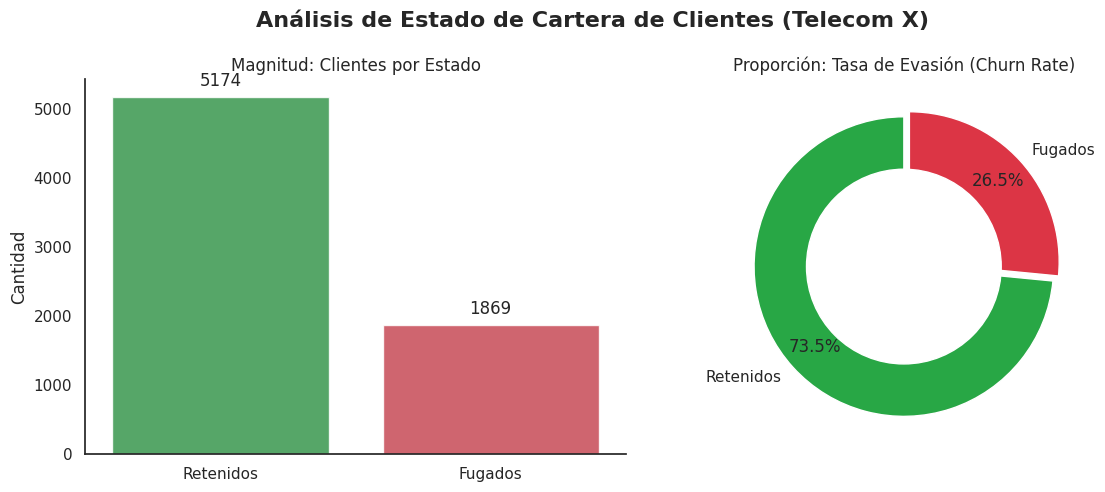

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# UI/UX ANALÍTICO: Estilización Global y Gráficos Modernos
# ==============================================================================

# 1. Configuración del Tema Global (Fondo blanco limpio, texto tamaño presentación)
sns.set_theme(style="white", context="notebook")

colores = ['#28a745', '#dc3545']
conteo = df['Evasion'].value_counts()

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Análisis de Estado de Cartera de Clientes (Telecom X)', fontsize=16, fontweight='bold')

# ------------------------------------------------------------------------------
# SUBPLOT 1: Barras Minimalistas (con despine y .set)
# ------------------------------------------------------------------------------
sns.countplot(
    data=df, x='Evasion', hue='Evasion', palette=colores,
    ax=ejes[0], legend=False, alpha=0.85 # alpha suaviza un poco el color
)

# Refactorización Clean Code: Aplicamos todos los atributos en una sola línea
ejes[0].set(title='Magnitud: Clientes por Estado', xlabel='', ylabel='Cantidad', xticklabels=['Retenidos', 'Fugados'])

# Inyectamos los números sobre las barras
for p in ejes[0].patches:
    ejes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

# Eliminamos los bordes superior y derecho
sns.despine(ax=ejes[0])

# ------------------------------------------------------------------------------
# SUBPLOT 2: Gráfico de Anillo (Donut Chart)
# ------------------------------------------------------------------------------
# Creamos la torta base, pero alejamos un poco los porcentajes (pctdistance)
ejes[1].pie(conteo, labels=['Retenidos', 'Fugados'], autopct='%1.1f%%', colors=colores,
            startangle=90, explode=(0, 0.05), pctdistance=0.80)

# Dibujamos un círculo blanco perfecto y lo superponemos en el centro para crear el "Anillo"
centro_blanco = plt.Circle((0, 0), 0.65, fc='white')
ejes[1].add_artist(centro_blanco)

ejes[1].set_title('Proporción: Tasa de Evasión (Churn Rate)')

plt.tight_layout()
plt.show()

## Recuento de evasión por variables categóricas
Ahora, exploraremos cómo se distribuye la **evasión** según variables categóricas, como **género, tipo de contrato, método de pago**, entre otras.

Este análisis puede revelar **patrones interesantes**, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a **orientar acciones estratégicas**.

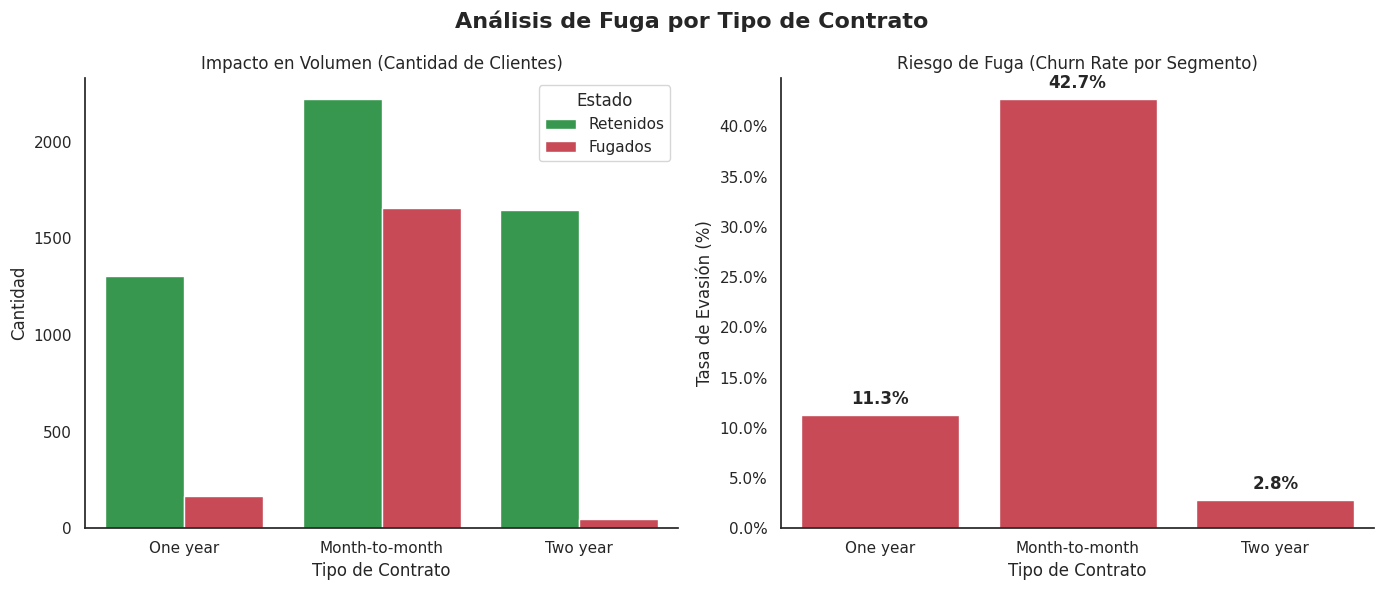

In [49]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick # Librería especial para formatear ejes como porcentajes
import seaborn as sns

# ==============================================================================
# SEGMENTACIÓN: Cruce Categórico (Variable 'Contrato' vs 'Evasion')
# ==============================================================================

# 1. Arquitectura del Lienzo (1 fila, 2 columnas)
fig, ejes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Análisis de Fuga por Tipo de Contrato', fontsize=16, fontweight='bold')
colores = ['#28a745', '#dc3545'] # Verde (Retenidos) y Rojo (Fugados)

# ------------------------------------------------------------------------------
# SUBPLOT 1: Camino A - Volumen Absoluto (Countplot)
# ------------------------------------------------------------------------------
# hue='Evasion' divide cada barra de contrato en dos colores (retenidos vs fugados)
sns.countplot(data=df, x='Contrato', hue='Evasion', palette=colores, ax=ejes[0])

ejes[0].set(title='Impacto en Volumen (Cantidad de Clientes)', xlabel='Tipo de Contrato', ylabel='Cantidad')
ejes[0].legend(title='Estado', labels=['Retenidos', 'Fugados']) # Leyenda limpia
sns.despine(ax=ejes[0]) # Minimalismo

# ------------------------------------------------------------------------------
# SUBPLOT 2: Camino B - Riesgo Relativo / Tasa de Fuga (Barplot)
# ------------------------------------------------------------------------------
# Un barplot en Seaborn calcula la media por defecto. Media de (0,0,1,0) = 0.25 = 25% Fuga
sns.barplot(data=df, x='Contrato', y='Evasion', color='#dc3545', ax=ejes[1], errorbar=None)

ejes[1].set(title='Riesgo de Fuga (Churn Rate por Segmento)', xlabel='Tipo de Contrato', ylabel='Tasa de Evasión (%)')

# Formateamos el Eje Y para que muestre porcentajes (20%, 40%) en lugar de decimales (0.2, 0.4)
ejes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Inyectamos los porcentajes exactos sobre cada barra roja
for p in ejes[1].patches:
    ejes[1].annotate(f'{p.get_height():.1%}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5), textcoords='offset points')

sns.despine(ax=ejes[1])

# Renderizado final
plt.tight_layout()
plt.show()

In [50]:
def auditar_variable(df: pd.DataFrame, columna: str, objetivo: str = 'Evasion') -> None:
    sns.set_theme(style="white")
    fig, ejes = plt.subplots(1, 2, figsize=(15, 6))
    colores = ['#28a745', '#dc3545']

    fig.suptitle(f'Auditoría de Negocio: {columna.replace("_", " ")}',
                 fontsize=16, fontweight='bold')

    # --------------------------------------------------------------------------
    # 1. TRADUCTOR INTELIGENTE (Lógica de Negocio)
    # --------------------------------------------------------------------------
    if columna == 'Genero':
        traductor = {0: 'Hombre', 1: 'Mujer'}
    else:
        traductor = {0: 'No', 1: 'Sí'}

    # --------------------------------------------------------------------------
    # SUBPLOT 1: Volumen
    # --------------------------------------------------------------------------
    sns.countplot(data=df, x=columna, hue=objetivo, palette=colores, ax=ejes[0])

    # Aplicamos traducción y rotación si es necesario
    labels = []
    for t in ejes[0].get_xticklabels():
        texto = t.get_text()
        # Intentamos traducir si es '0' o '1', sino dejamos el texto original
        labels.append(traductor.get(int(texto), texto) if texto in ['0', '1'] else texto)

    ejes[0].set_xticks(range(len(labels)))
    ejes[0].set_xticklabels(labels, rotation=45 if columna == 'Metodo_Pago' else 0)

    ejes[0].set(title='Impacto en Volumen', xlabel='', ylabel='Clientes')
    ejes[0].legend(title='¿Se fue?', labels=['No', 'Sí'])
    sns.despine(ax=ejes[0])

    # --------------------------------------------------------------------------
    # SUBPLOT 2: Riesgo
    # --------------------------------------------------------------------------
    sns.barplot(data=df, x=columna, y=objetivo, color='#dc3545', ax=ejes[1], errorbar=None)

    ejes[1].set_xticks(range(len(labels)))
    ejes[1].set_xticklabels(labels, rotation=45 if columna == 'Metodo_Pago' else 0)

    ejes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ejes[1].set(title='Riesgo Relativo (Churn Rate)', xlabel='', ylabel='Probabilidad')

    for p in ejes[1].patches:
        valor = p.get_height()
        if valor > 0:
            ejes[1].annotate(f'{valor:.1%}', (p.get_x() + p.get_width() / 2., valor),
                             ha='center', va='bottom', fontsize=11, fontweight='bold',
                             xytext=(0, 5), textcoords='offset points')

    sns.despine(ax=ejes[1])
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


🔍 ANALIZANDO SEGMENTO: GENERO



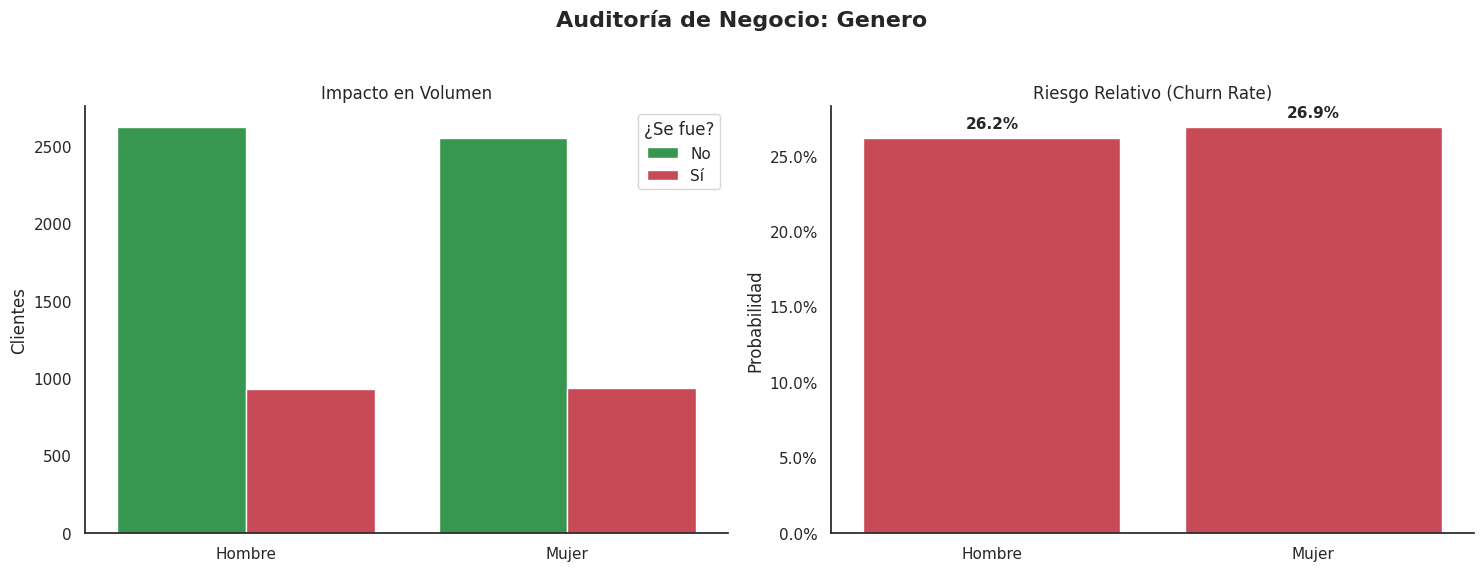


FIN DEL ANÁLISIS PARA: Genero
----------------------------------------

🔍 ANALIZANDO SEGMENTO: ADULTO_MAYOR



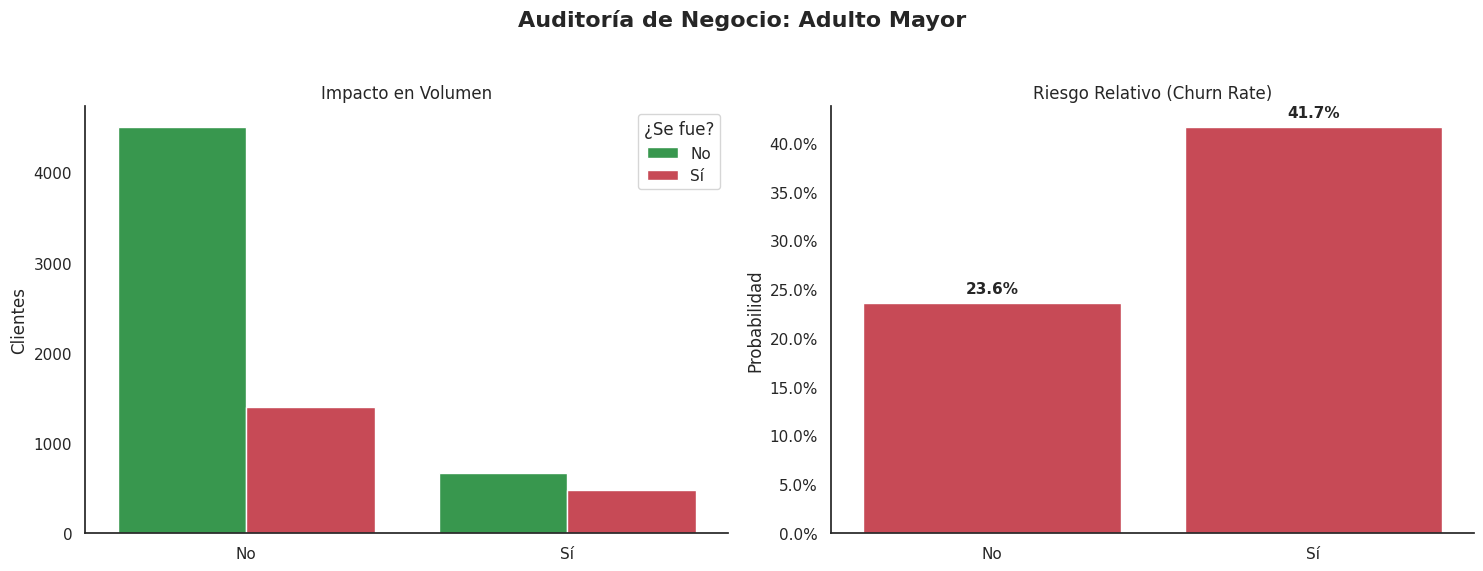


FIN DEL ANÁLISIS PARA: Adulto_Mayor
----------------------------------------

🔍 ANALIZANDO SEGMENTO: PAREJA



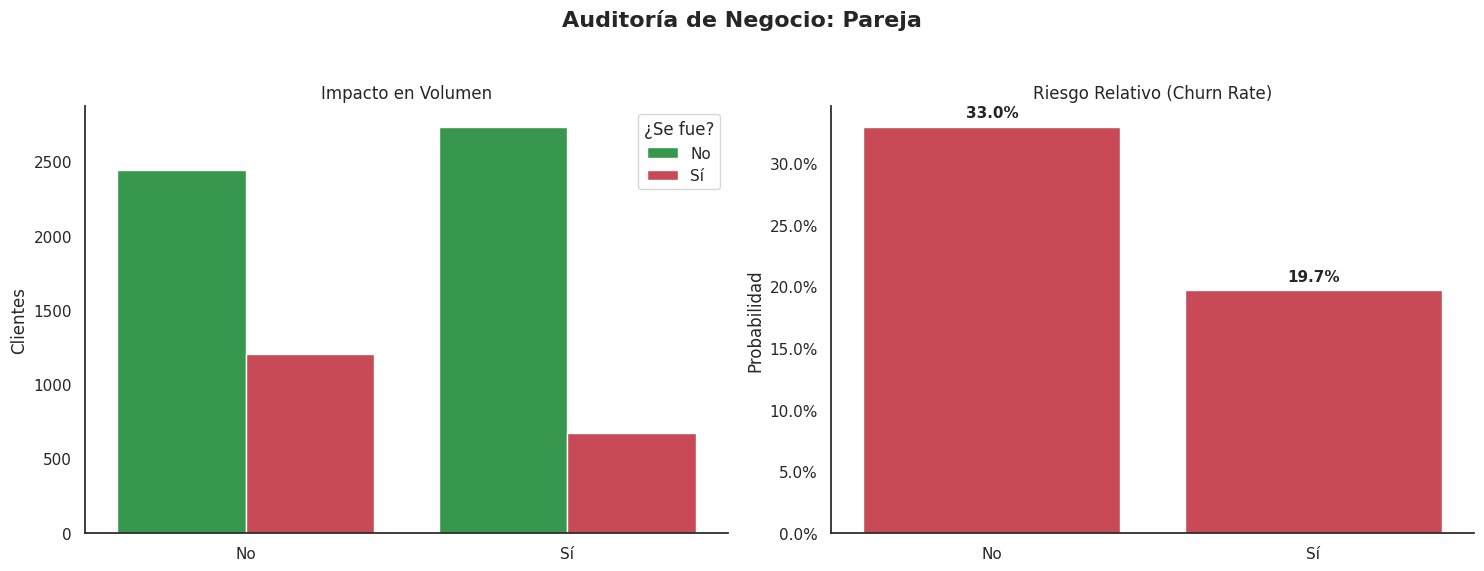


FIN DEL ANÁLISIS PARA: Pareja
----------------------------------------

🔍 ANALIZANDO SEGMENTO: DEPENDIENTES



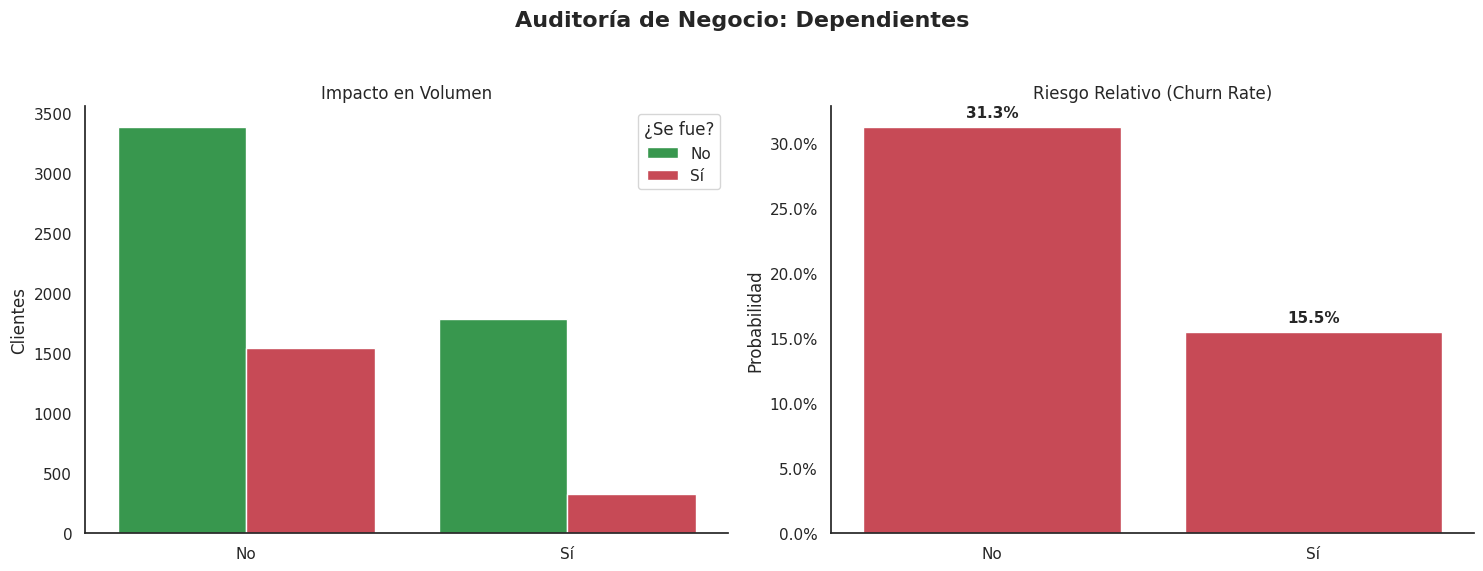


FIN DEL ANÁLISIS PARA: Dependientes
----------------------------------------

🔍 ANALIZANDO SEGMENTO: SERVICIO_TELEFONICO



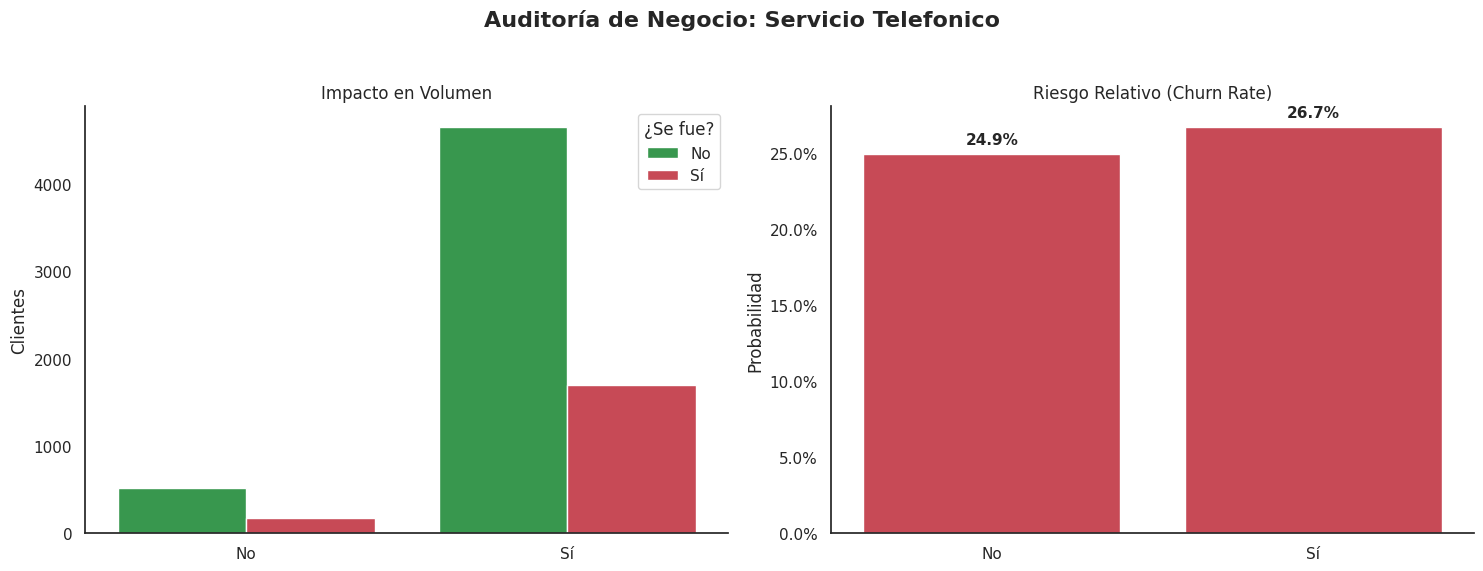


FIN DEL ANÁLISIS PARA: Servicio_Telefonico
----------------------------------------

🔍 ANALIZANDO SEGMENTO: MULTIPLES_LINEAS



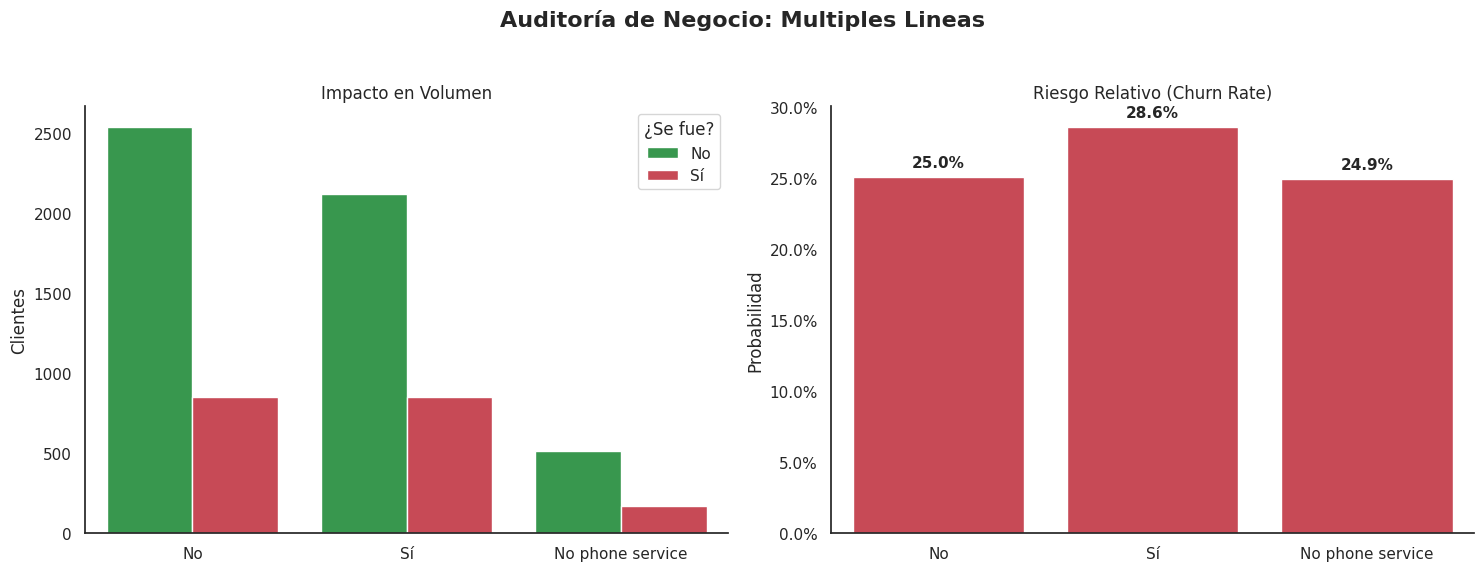


FIN DEL ANÁLISIS PARA: Multiples_Lineas
----------------------------------------

🔍 ANALIZANDO SEGMENTO: SERVICIO_INTERNET



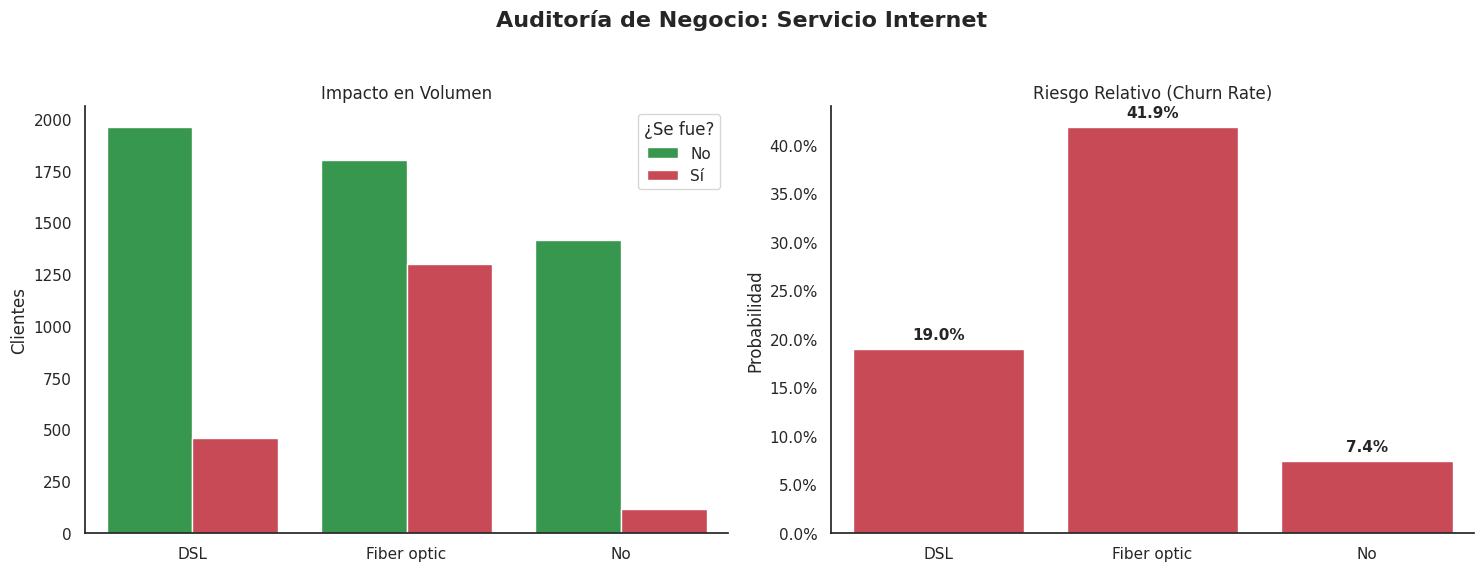


FIN DEL ANÁLISIS PARA: Servicio_Internet
----------------------------------------

🔍 ANALIZANDO SEGMENTO: SEGURIDAD_ONLINE



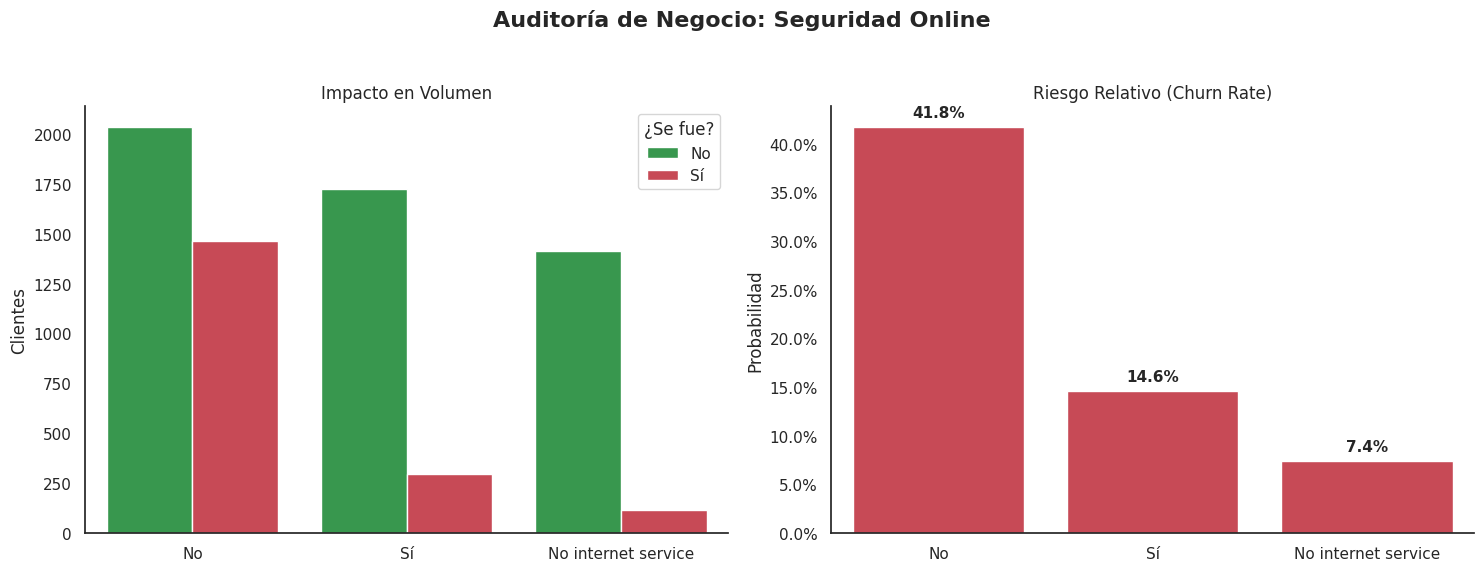


FIN DEL ANÁLISIS PARA: Seguridad_Online
----------------------------------------

🔍 ANALIZANDO SEGMENTO: RESPALDO_ONLINE



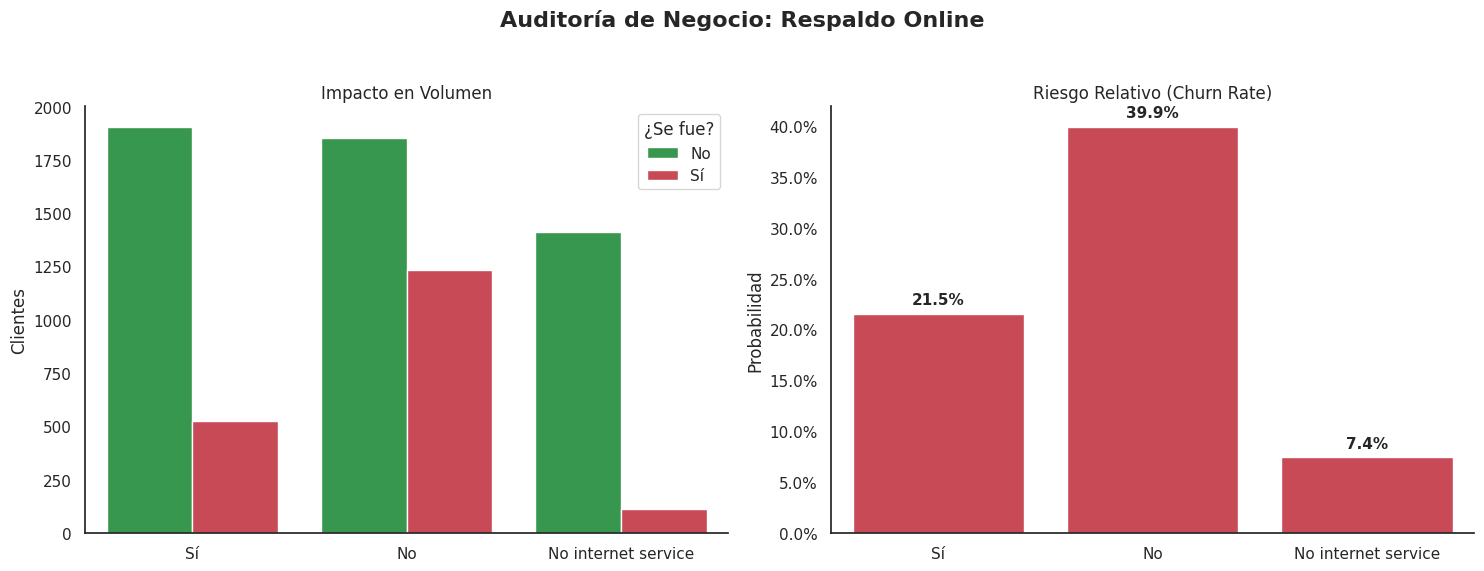


FIN DEL ANÁLISIS PARA: Respaldo_Online
----------------------------------------

🔍 ANALIZANDO SEGMENTO: PROTECCION_DISPOSITIVO



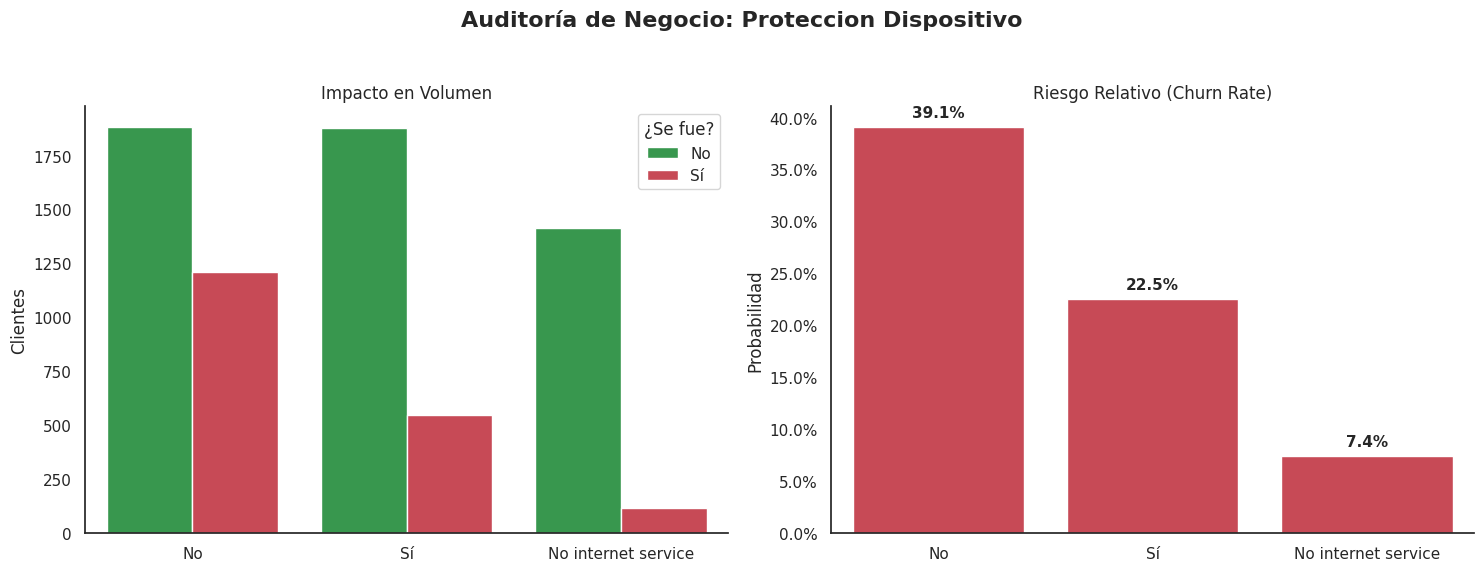


FIN DEL ANÁLISIS PARA: Proteccion_Dispositivo
----------------------------------------

🔍 ANALIZANDO SEGMENTO: SOPORTE_TECNICO



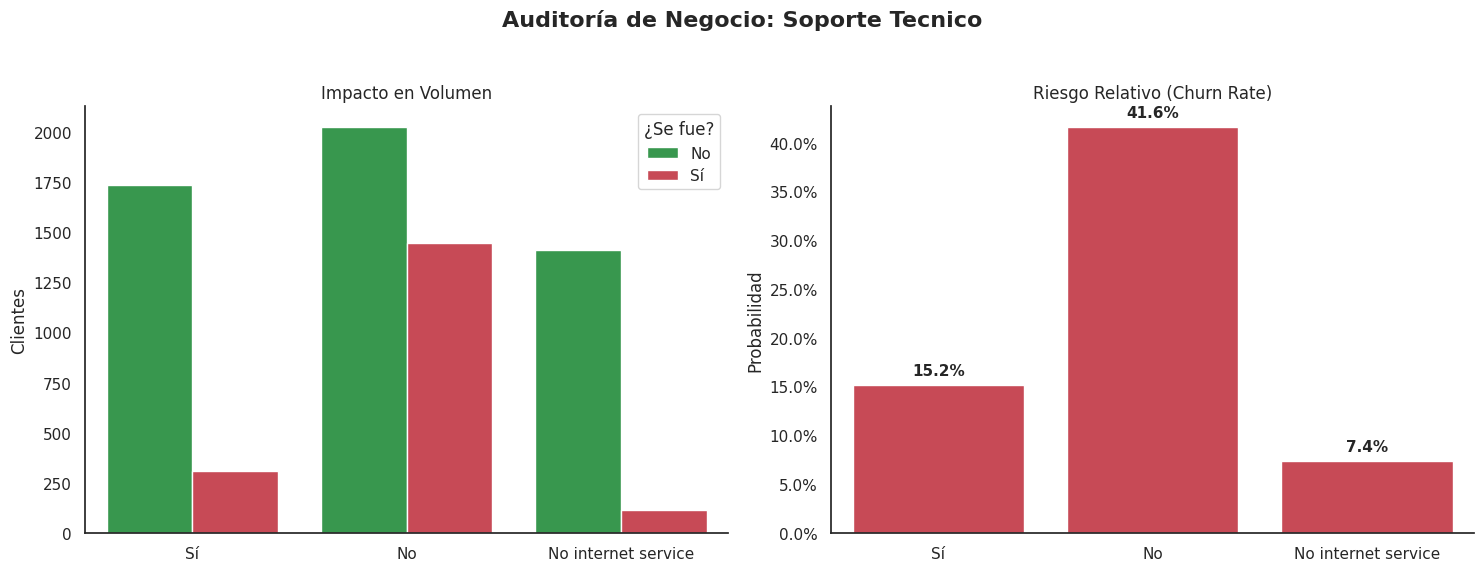


FIN DEL ANÁLISIS PARA: Soporte_Tecnico
----------------------------------------

🔍 ANALIZANDO SEGMENTO: STREAMING_TV



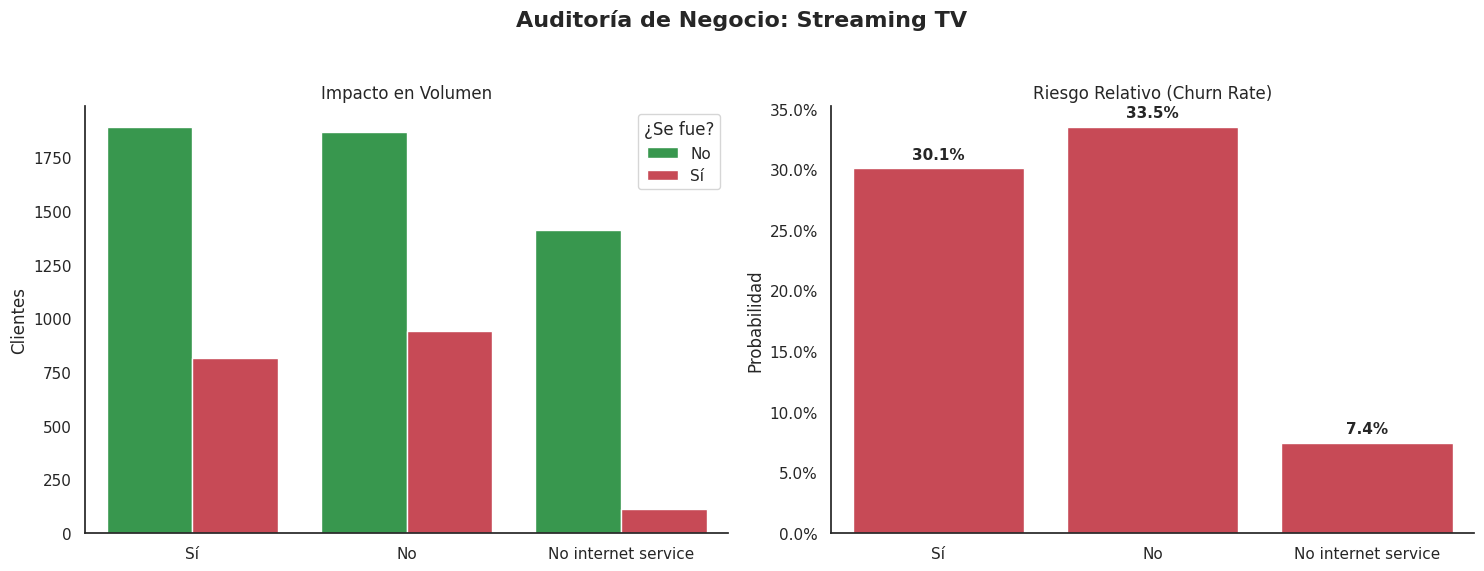


FIN DEL ANÁLISIS PARA: Streaming_TV
----------------------------------------

🔍 ANALIZANDO SEGMENTO: STREAMING_PELICULAS



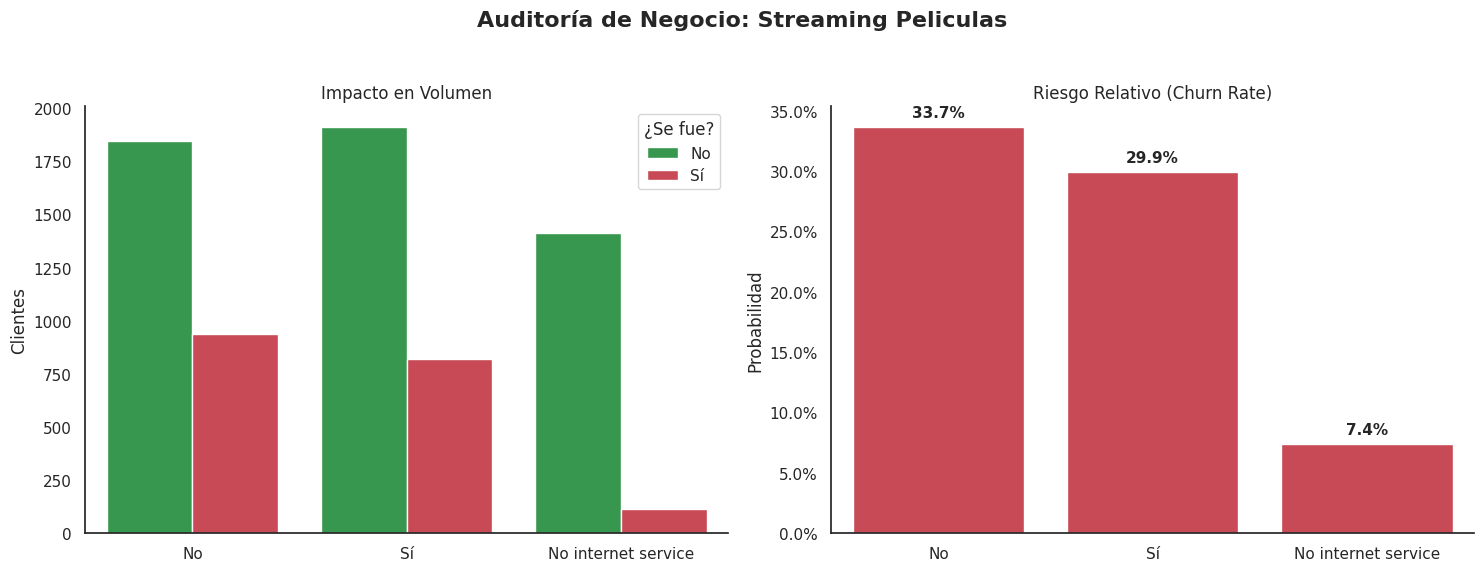


FIN DEL ANÁLISIS PARA: Streaming_Peliculas
----------------------------------------

🔍 ANALIZANDO SEGMENTO: CONTRATO



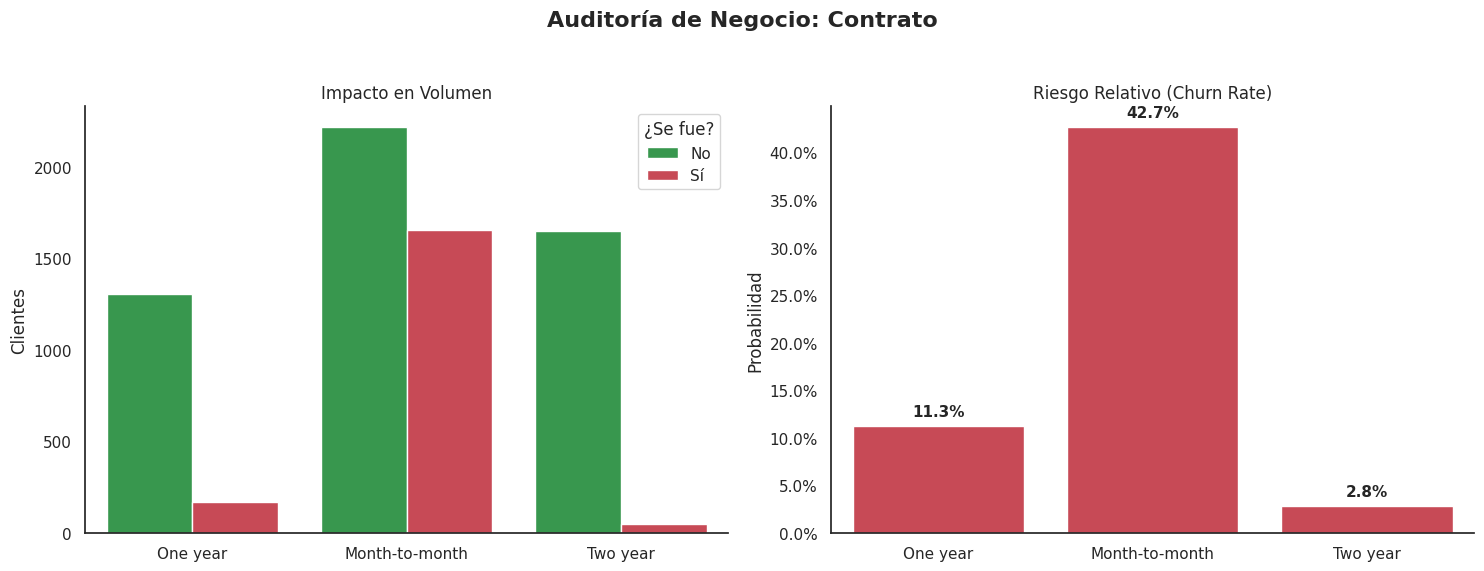


FIN DEL ANÁLISIS PARA: Contrato
----------------------------------------

🔍 ANALIZANDO SEGMENTO: FACTURACION_ELECTRONICA



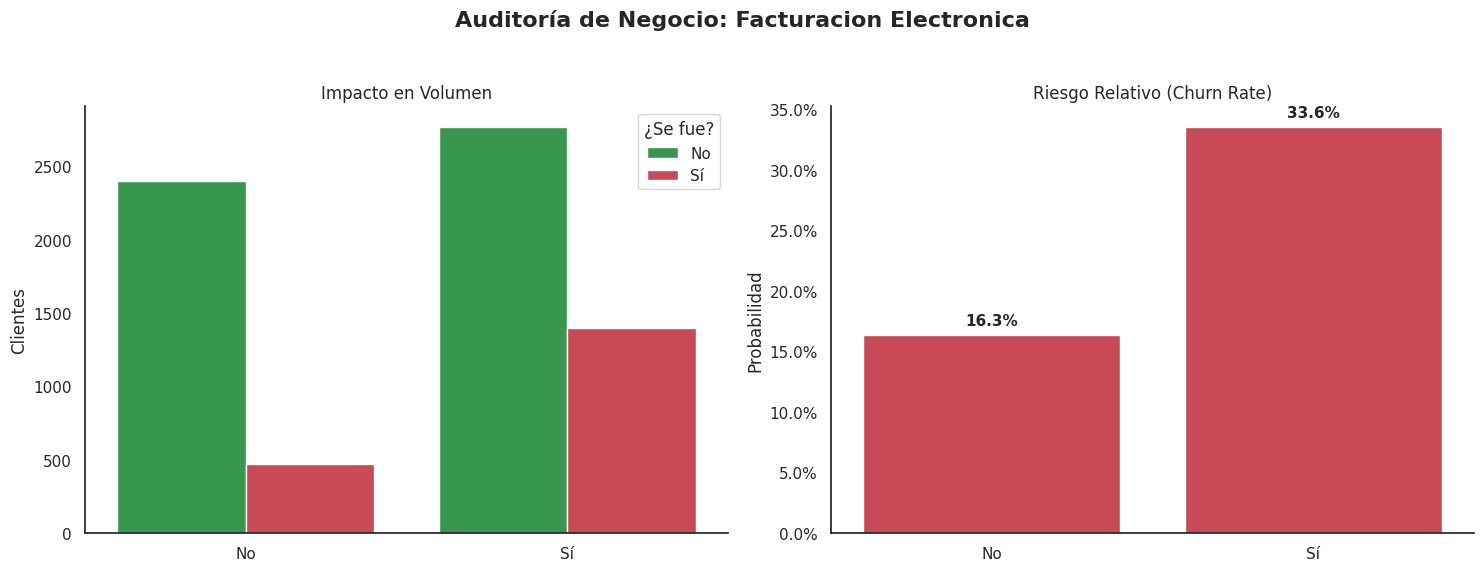


FIN DEL ANÁLISIS PARA: Facturacion_Electronica
----------------------------------------

🔍 ANALIZANDO SEGMENTO: METODO_PAGO



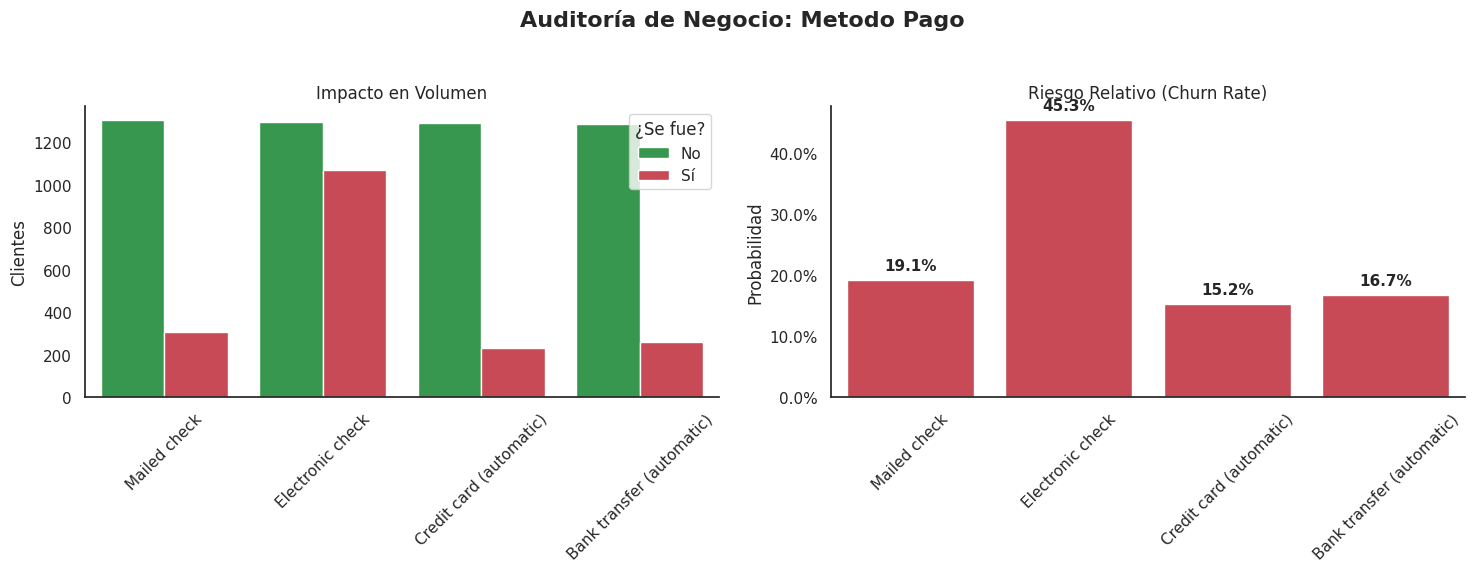


FIN DEL ANÁLISIS PARA: Metodo_Pago
----------------------------------------


In [51]:
# ==============================================================================
# AUDITORÍA MASIVA: Ejecución del Plan de Análisis Categórico
# ==============================================================================

# 1. Definimos la lista de "sospechosos" (variables categóricas)
columnas_categoricas = [
    'Genero', 'Adulto_Mayor', 'Pareja', 'Dependientes',
    'Servicio_Telefonico', 'Multiples_Lineas', 'Servicio_Internet',
    'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo',
    'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas',
    'Contrato', 'Facturacion_Electronica', 'Metodo_Pago'
]

# 2. Iteramos y auditamos
for col in columnas_categoricas:
    print(f"\n" + "="*80)
    print(f"🔍 ANALIZANDO SEGMENTO: {col.upper()}")
    print("="*80 + "\n")

    # Llamamos a nuestra función estrella
    auditar_variable(df, col)

    print(f"\nFIN DEL ANÁLISIS PARA: {col}")
    print("-" * 40)

## Conteo de evasión por variables numéricas

En este paso, explora cómo las **variables numéricas**, como **"total gastado"** o **"tiempo de contrato"**, se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la **evasión**, proporcionando **insights** sobre los factores que influyen en el comportamiento de los clientes.

In [52]:
def analizar_num_distribucion(df: pd.DataFrame, columna: str, objetivo: str = 'Evasion') -> None:
    """
    Crea un gráfico de densidad (KDE) con rejilla y escala optimizada.
    """
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="white")

    # 1. Graficamos las curvas
    sns.kdeplot(data=df[df[objetivo] == 0], x=columna, fill=True, color='#28a745', label='Retenido', alpha=0.4)
    sns.kdeplot(data=df[df[objetivo] == 1], x=columna, fill=True, color='#dc3545', label='Fugado', alpha=0.4)

    # 2. Configuración de Escalas (Eje X)
    max_val = df[columna].max()
    # Si la variable es mayor a 10 (meses/cargos), saltamos de 10 en 10.
    # Si es menor (Cuentas Diarias), saltamos de 0.5 en 0.5
    paso = 10 if max_val > 10 else 0.5

    plt.xticks(np.arange(0, max_val + paso, paso))
    plt.xlim(0, max_val * 1.05) # Empezamos en 0 y damos un 5% de aire al final

    # 3. Cuadrícula y Estética
    plt.grid(visible=True, linestyle='--', alpha=0.3, color='gray') # Rejilla tenue
    plt.title(f'Análisis de Densidad: {columna.replace("_", " ")}', fontsize=14, fontweight='bold')
    plt.xlabel(f'Valor de {columna}')
    plt.ylabel('Concentración de Clientes')
    plt.legend(title='¿Se fue?')

    sns.despine() # Quitamos bordes innecesarios
    plt.show()


————————————————————————————————————————————————————————————————————————————————
📊 AUDITANDO VARIABLE NUMÉRICA: MESES_CONTRATO


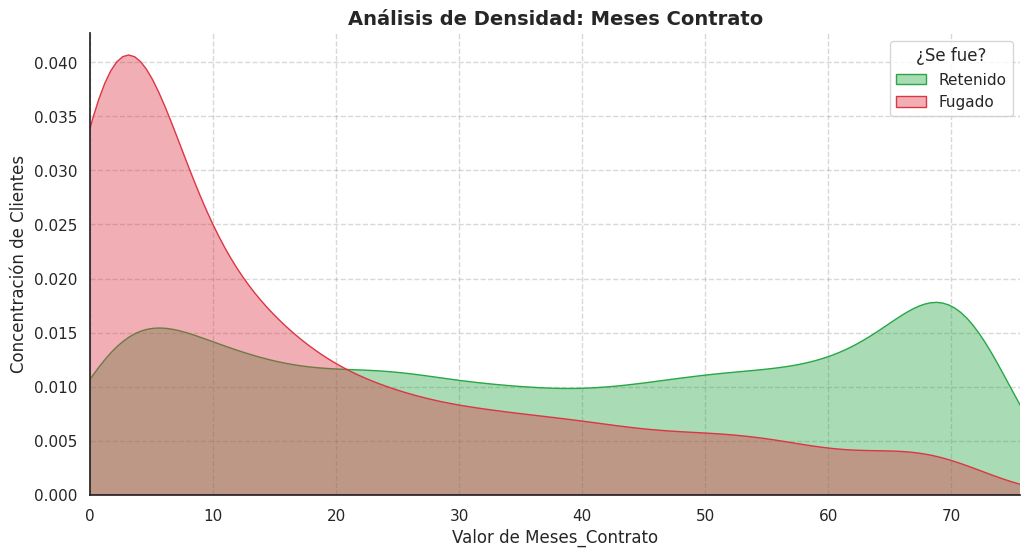


————————————————————————————————————————————————————————————————————————————————
📊 AUDITANDO VARIABLE NUMÉRICA: CARGO_MENSUAL


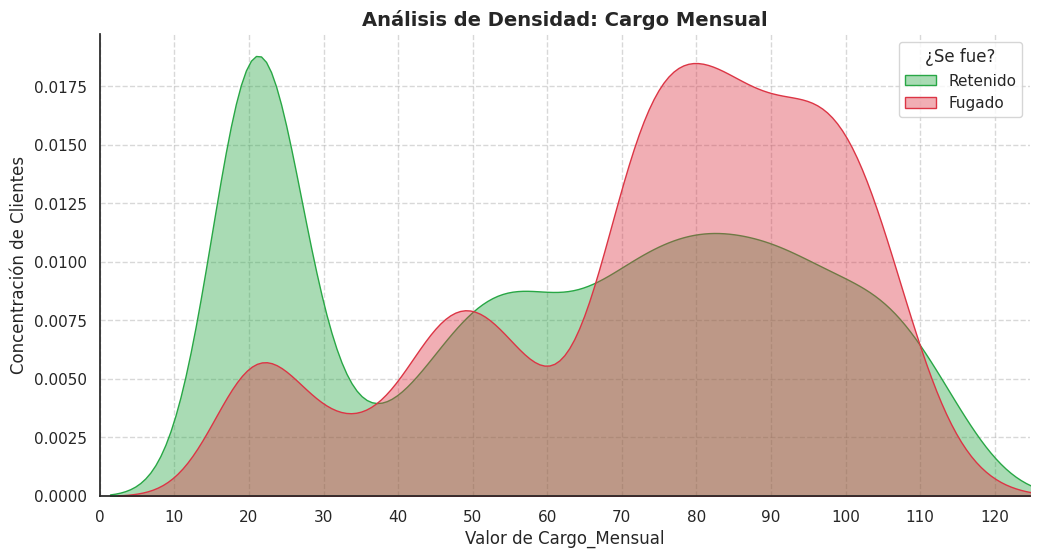


————————————————————————————————————————————————————————————————————————————————
📊 AUDITANDO VARIABLE NUMÉRICA: CARGO_TOTAL


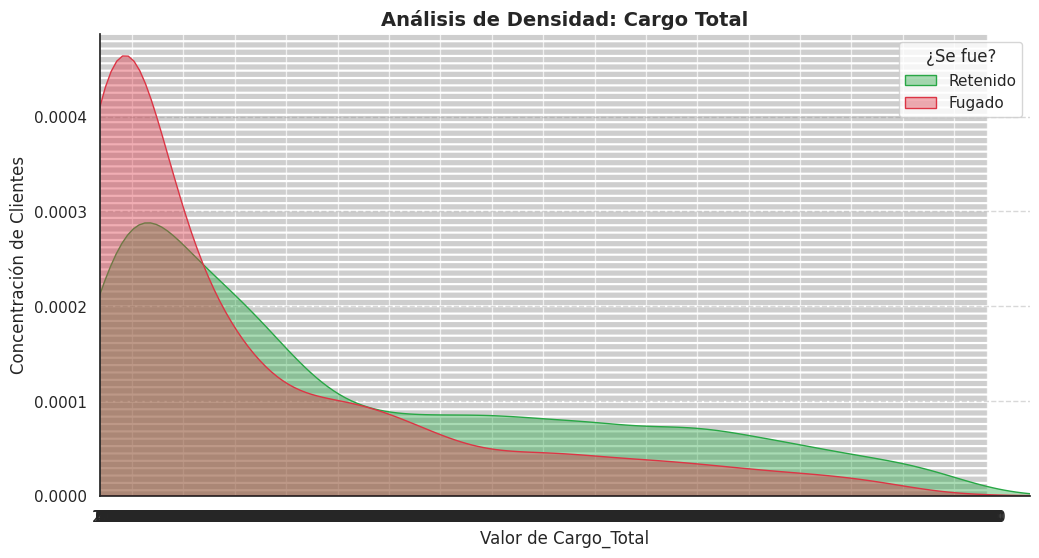


————————————————————————————————————————————————————————————————————————————————
📊 AUDITANDO VARIABLE NUMÉRICA: CUENTAS_DIARIAS


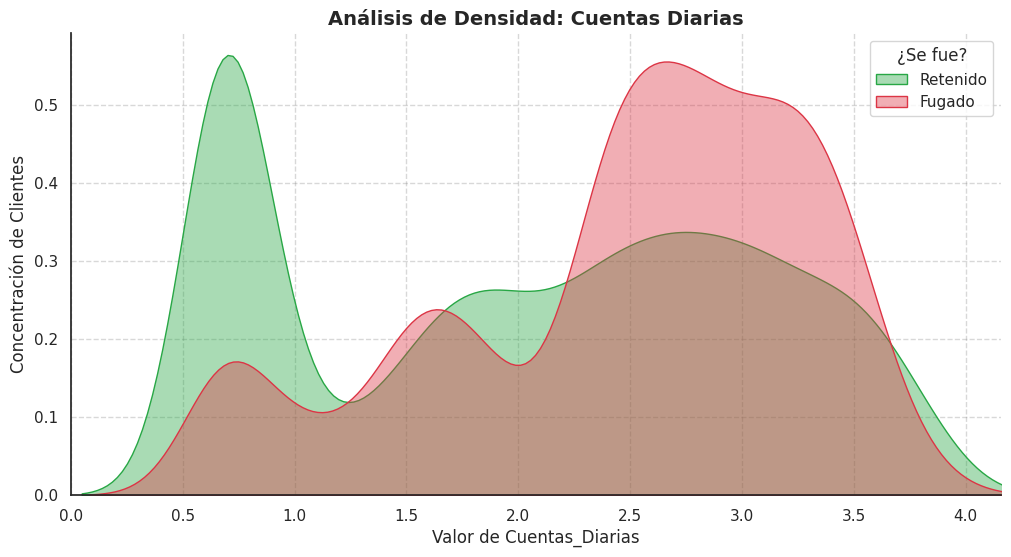

In [53]:
# Lista de variables numéricas para auditar
variables_num = ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']

for var in variables_num:
    print(f"\n" + "—"*80)
    print(f"📊 AUDITANDO VARIABLE NUMÉRICA: {var.upper()}")
    analizar_num_distribucion(df, var)

# ¡Extra! Análisis de correlación entre variables

Esta actividad es un extra, por lo tanto es **OPCIONAL.**

Como un paso adicional, puedes explorar la **correlación** entre diferentes variables del dataset. Esto puede ayudar a identificar qué factores tienen **mayor relación con la evasión de clientes**, como:

🔹 La relación entre la **cuenta diaria** y la evasión.
🔹 Cómo la **cantidad de servicios contratados** afecta la probabilidad de churn.

Puedes usar la función `corr()` de Pandas para calcular las correlaciones y visualizar los resultados con **gráficos de dispersión** o **matrices de correlación**.

Este análisis adicional puede proporcionar **insights valiosos** para la creación de modelos predictivos más robustos. 🚀

In [54]:
# ==============================================================================
# FEATURE ENGINEERING: Validando las sospechas del Analista
# ==============================================================================

# 1. Definimos los grupos de servicios para el cálculo
servicios_seguridad = ['Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico']
servicios_entretenimiento = ['Streaming_TV', 'Streaming_Peliculas']

# 2. Creamos el "Puntaje Inseguro"
# Como 'No' es 0 y 'Sí' es 1, al restar (1 - valor) convertimos el 'No' en un punto de riesgo.
# Nota: Si el valor es texto (ej. 'No internet service'), lo tratamos como 0 para el cálculo.
df['Puntaje_Inseguro'] = df[servicios_seguridad].apply(pd.to_numeric, errors='coerce').fillna(0).apply(lambda x: 1 - x).sum(axis=1)

# 3. Creamos "Total_Servicios"
# Simplemente sumamos todos los 1s que encontremos en las columnas de servicios
todas_las_ventas = servicios_seguridad + servicios_entretenimiento + ['Servicio_Telefonico']
df['Total_Servicios'] = df[todas_las_ventas].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1)

print("✅ Columnas de hipótesis creadas exitosamente.")
display(df[['ID_Cliente', 'Puntaje_Inseguro', 'Total_Servicios']].head())

✅ Columnas de hipótesis creadas exitosamente.


,ID_Cliente,Puntaje_Inseguro,Total_Servicios
0,0002-ORFBO,2.0,4.0
1,0003-MKNFE,4.0,2.0
2,0004-TLHLJ,3.0,2.0
3,0011-IGKFF,2.0,5.0
4,0013-EXCHZ,3.0,3.0


/tmp/ipython-input-2573307993.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fuga_rank.values, y=fuga_rank.index, palette='RdYlGn_r', ax=ejes[1])


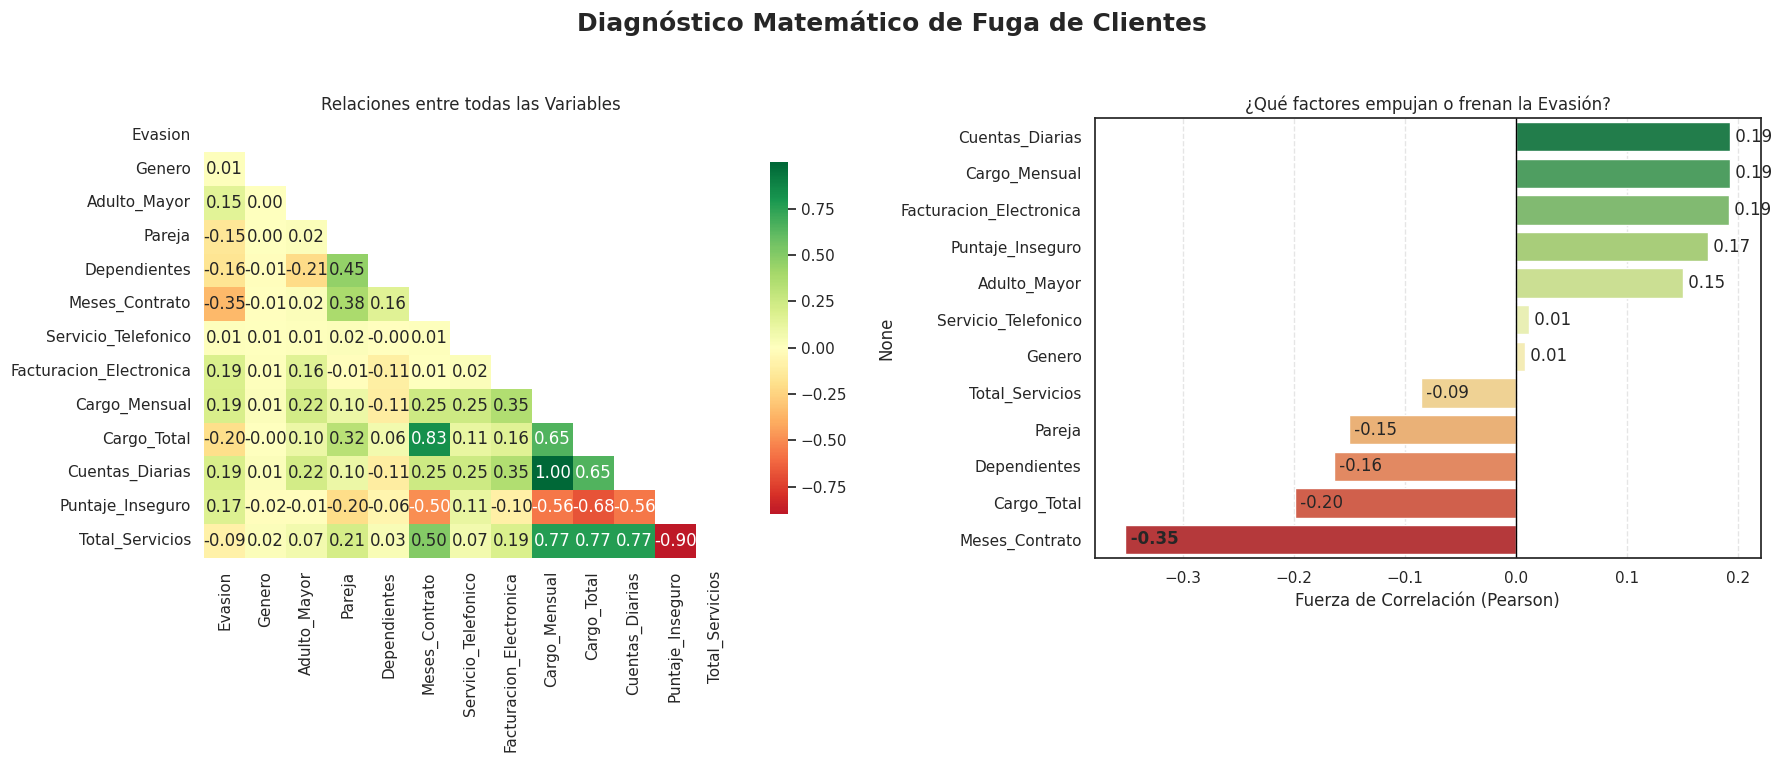

In [55]:
import numpy as np

# ==============================================================================
# ANÁLISIS DE CORRELACIÓN: El Escáner de Responsabilidades
# ==============================================================================

# 1. Seleccionamos solo las columnas numéricas (incluyendo las nuevas hipótesis)
# Excluimos ID_Cliente porque es un texto identificador
df_corr = df.select_dtypes(include=[np.number])

# 2. Calculamos la matriz de Pearson
matriz = df_corr.corr()

# 3. Configuramos el lienzo para dos gráficos
fig, ejes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Diagnóstico Matemático de Fuga de Clientes', fontsize=18, fontweight='bold')

# ------------------------------------------------------------------------------
# GRÁFICO 1: Matriz Global (Heatmap)
# ------------------------------------------------------------------------------
# Usamos una máscara para ver solo la mitad inferior (evita duplicidad visual)
mask = np.triu(np.ones_like(matriz, dtype=bool))

sns.heatmap(matriz, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn',
            center=0, ax=ejes[0], cbar_kws={"shrink": .8})
ejes[0].set_title('Relaciones entre todas las Variables')

# ------------------------------------------------------------------------------
# GRÁFICO 2: Foco en la Evasión (El ranking de "Culpables")
# ------------------------------------------------------------------------------
# Extraemos solo la columna de Evasion y la ordenamos
fuga_rank = matriz['Evasion'].sort_values(ascending=False).drop('Evasion')

sns.barplot(x=fuga_rank.values, y=fuga_rank.index, palette='RdYlGn_r', ax=ejes[1])
ejes[1].set_title('¿Qué factores empujan o frenan la Evasión?')
ejes[1].set_xlabel('Fuerza de Correlación (Pearson)')
ejes[1].axvline(x=0, color='black', linestyle='-', linewidth=1) # Línea de neutralidad
ejes[1].grid(axis='x', linestyle='--', alpha=0.5)

# Inyectamos los valores exactos para precisión analítica
for i, v in enumerate(fuga_rank.values):
    ejes[1].text(v, i, f' {v:.2f}', va='center', fontweight='bold' if abs(v) > 0.3 else 'normal')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 🧠 Interpretación de Métricas de Correlación (Pearson)

El Coeficiente de Correlación de Pearson ($r$) mide la relación lineal entre dos variables en un rango de **-1 a +1**.

1. **Correlación Positiva (+):** Las variables se mueven en la misma dirección.
   - *Ejemplo:* Si sube el `Puntaje_Inseguro`, sube la probabilidad de `Evasión`. Son factores de riesgo.
2. **Correlación Negativa (-):** Tienen una relación inversa.
   - *Ejemplo:* A más `Meses_Contrato`, menor es la `Evasión`. Son factores de retención o "anclas".
3. **Magnitud del Valor:** - Cercano a **0**: No hay relación (ruido).
   - Cercano a **0.3 / 0.5**: Relación moderada a fuerte. En nuestro caso, los **Meses de Contrato (-0.35)** son el predictor más sólido.

#📄Informe final

Finaliza el desafío elaborando un **informe dentro del mismo notebook** que resuma todo el trabajo realizado. El informe debe incluir:

🔹 **Introducción:** Explica el objetivo del análisis y el problema de **evasión de clientes (Churn)**.

🔹 **Limpieza y Tratamiento de Datos:** Describe los pasos realizados para **importar, limpiar y procesar** los datos.

🔹 **Análisis Exploratorio de Datos:** Presenta los análisis realizados, incluyendo **gráficos y visualizaciones** para identificar patrones.

🔹 **Conclusiones e Insights:** Resume los principales hallazgos y cómo estos datos pueden ayudar a **reducir la evasión**.

🔹 **Recomendaciones:** Ofrece **sugerencias estratégicas** basadas en tu análisis.

Asegúrate de que el informe esté **bien estructurado, claro y respaldado por visualizaciones** que refuercen tus conclusiones. 🚀

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import numpy as np

# Configuración estética global
sns.set_theme(style="white", context="notebook")
colores = ['#28a745', '#dc3545']

# --- 1. Distribución General de Evasión ---
fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='Evasion', hue='Evasion', palette=colores, ax=ejes[0], legend=False)
ejes[0].set(title='Volumen de Clientes', xlabel='', ylabel='Cantidad', xticklabels=['Retenidos', 'Fugados'])
for p in ejes[0].patches:
    ejes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
sns.despine(ax=ejes[0])
ejes[1].pie(df['Evasion'].value_counts(), labels=['Retenidos', 'Fugados'], autopct='%1.1f%%', colors=colores, startangle=90, explode=(0, 0.05))
centro = plt.Circle((0,0), 0.70, fc='white')
ejes[1].add_artist(centro)
plt.savefig('/content/distribucion_evasion.png', bbox_inches='tight')
plt.close()

# --- 2. Análisis de Contrato (El factor clave) ---
fig, ejes = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=df, x='Contrato', hue='Evasion', palette=colores, ax=ejes[0])
ejes[0].set(title='Volumen por Contrato', xlabel='')
sns.barplot(data=df, x='Contrato', y='Evasion', color='#dc3545', ax=ejes[1], errorbar=None)
ejes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ejes[1].set(title='Riesgo de Fuga (%)', xlabel='')
plt.savefig('/content/analisis_contrato.png', bbox_inches='tight')
plt.close()

# --- 3. Análisis de Método de Pago (Variables largas) ---
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, x='Metodo_Pago', y='Evasion', color='#dc3545', errorbar=None)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.title('Riesgo por Método de Pago')
plt.savefig('/content/analisis_pago.png', bbox_inches='tight')
plt.close()

# --- 4. Distribución Numérica (Tenure y Cargo) ---
fig, ejes = plt.subplots(1, 2, figsize=(14, 6))
sns.kdeplot(data=df, x='Meses_Contrato', hue='Evasion', fill=True, palette=colores, ax=ejes[0])
ejes[0].set(title='Densidad: Meses de Contrato', xlim=(0, df['Meses_Contrato'].max()))
sns.kdeplot(data=df, x='Cargo_Mensual', hue='Evasion', fill=True, palette=colores, ax=ejes[1])
ejes[1].set(title='Densidad: Cargo Mensual')
plt.savefig('/content/densidad_numerica.png', bbox_inches='tight')
plt.close()

# --- 5. Matriz de Correlación e Influencia ---
matriz = df.select_dtypes(include=[np.number]).corr()
fig, ejes = plt.subplots(1, 2, figsize=(18, 8))
mask = np.triu(np.ones_like(matriz, dtype=bool))
sns.heatmap(matriz, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn', center=0, ax=ejes[0])
fuga_rank = matriz['Evasion'].sort_values(ascending=False).drop('Evasion')
sns.barplot(x=fuga_rank.values, y=fuga_rank.index, palette='RdYlGn_r', ax=ejes[1])
ejes[1].set(title='Ranking de Influencia en Churn')
plt.savefig('/content/correlacion_final.png', bbox_inches='tight')
plt.close()

print("✅ Todas las imágenes han sido exportadas a /content/")

/tmp/ipython-input-3100366228.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ejes[0].set(title='Volumen de Clientes', xlabel='', ylabel='Cantidad', xticklabels=['Retenidos', 'Fugados'])
/tmp/ipython-input-3100366228.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fuga_rank.values, y=fuga_rank.index, palette='RdYlGn_r', ax=ejes[1])


✅ Todas las imágenes han sido exportadas a /content/


# 📄 Informe Final: Análisis de Evasión de Clientes (Churn)
**Proyecto:** Alura

**Autor:** Miyen (Lic. en Informática - UNPSJB)

---

## 1. Introducción
El objetivo de este análisis es identificar los factores que impulsan la **evasión de clientes (Churn)** en la empresa de servicios Telecom X. En un mercado altamente competitivo, retener a un cliente existente es significativamente más rentable que adquirir uno nuevo. Este informe busca transformar datos crudos en **insights estratégicos** para reducir la pérdida de clientes y optimizar la rentabilidad de la PyME.

## 2. Limpieza y Tratamiento de Datos
Para garantizar la calidad del análisis, se llevaron a cabo los siguientes pasos técnicos:
* **Importación y Aplanamiento:** Los datos se extrajeron de una estructura anidada (JSON/Diccionarios) y se transformaron en un DataFrame plano.
* **Traducción y Binarización:** Se estandarizaron las columnas al español y se convirtieron las variables categóricas (Sí/No) a valores booleanos (1/0) para permitir el procesamiento estadístico.
* **Ingeniería de Atributos (Feature Engineering):**
    * Se creó la métrica **Cuentas_Diarias** para entender el impacto del gasto micro-diario.
    * Se desarrollaron los indicadores **Puntaje_Inseguro** y **Total_Servicios** para validar hipótesis sobre la lealtad técnica del cliente.
* **Tratamiento de Nulos:** Se identificaron y corrigieron valores nulos en la columna `Cargo_Total`.

## 3. Análisis Exploratorio de Datos (EDA)

### 3.1. Estado Actual de la Cartera
La empresa presenta una tasa de evasión del **26.5%**. Aunque la mayoría de los clientes permanecen, el volumen de fugas (1,869 clientes) requiere atención inmediata.

![Distribución General](/content/distribucion_evasion.png)  
*[distribucion_evasion.png: Gráfico de barras y anillo mostrando la proporción de clientes retenidos vs fugados]*

### 3.2. Identificación de Factores Críticos
El análisis reveló que el **Tipo de Contrato** es el predictor más fuerte. Los clientes con contratos mensuales tienen un riesgo de fuga del **42.7%**, evidenciando una falta de compromiso a largo plazo.

![Análisis por Contrato](/content/analisis_contrato.png)  
*[analisis_contrato.png: Comparativa de volumen y tasa de riesgo según la duración del contrato]*

Asimismo, el **Método de Pago** influye drásticamente: los clientes que pagan mediante "Cheque Electrónico" tienen una tendencia a la evasión mucho mayor que aquellos con débito automático.

![Análisis por Método de Pago](/content/analisis_pago.png)  
*[analisis_pago.png: Gráfico de barras mostrando el riesgo relativo según el medio de pago utilizado]*

### 3.3. Comportamiento Numérico y Temporicidad
Se detectó un "punto crítico" de deserción entre los **0 y 10 meses** de antigüedad. Si un cliente supera el primer año, la probabilidad de fuga cae drásticamente. Respecto al costo, los clientes con cargos superiores a **$70** mensuales presentan la mayor inestabilidad.

![Densidad Numérica](/content/densidad_numerica.png)  
*[densidad_numerica.png: Gráficos KDE que comparan la distribución de meses de contrato y cargos mensuales entre clientes fugados y retenidos]*

## 4. Conclusiones e Insights
* **La Antigüedad es el Ancla:** Existe una correlación negativa fuerte (-0.35) entre los meses de contrato y la evasión.
* **Hipótesis del "Inseguro Digital":** Se confirmó que la falta de servicios de seguridad y soporte técnico correlaciona positivamente con la fuga (+0.17). Los clientes con menor "vínculo técnico" se van más fácil.
* **Impacto del Precio:** El costo diario percibido (`Cuentas_Diarias`) y el cargo mensual actúan como aceleradores de la evasión cuando superan ciertos umbrales psicológicos.

![Correlación e Influencia](/content/correlacion_final.png)  
*[correlacion_final.png: Mapa de calor global y ranking de las variables con mayor impacto matemático sobre el Churn]*

## 5. Recomendaciones Estratégicas
1. **Plan de Fidelización Temprana:** Implementar incentivos automáticos (descuentos o servicios extra) durante los primeros 6 meses de vida del cliente.
2. **Migración Contractual:** Diseñar campañas para convertir clientes "Mes a mes" a planes anuales, enfocándose en aquellos que utilizan "Cheque Electrónico".
3. **Estrategia de Seguridad Online:** Ofrecer el paquete de seguridad y soporte técnico como un beneficio bonificado para aumentar el "costo de salida" y reducir el `Puntaje_Inseguro`.
4. **Optimización de Métodos de Pago:** Incentivar el registro de tarjetas de crédito o débito automático para reducir la fricción del pago manual que facilita la evasión.

# 📊 Informe Técnico-Gerencial: Análisis de Evasión de Clientes (Churn)
**Proyecto:** Alura
**Analista:** Miyen, Estudiante de 3º año de Lic. en Informática (UNPSJB)
**Fecha:** 24 de febrero de 2026

---

## 1. Introducción y Metodología
El presente informe detalla el proceso de **Análisis Exploratorio de Datos (EDA)** aplicado a la cartera de clientes de "Telecom X", con el objetivo de identificar patrones que permitan predecir y prevenir la evasión (Churn). Se han aplicado principios de *Clean Code* y estandarización de datos para asegurar la robustez del análisis.

**Metodología aplicada:**
1. **ETL:** Limpieza, traducción y binarización de variables categóricas.
2. **Feature Engineering:** Creación de indicadores de negocio (`Puntaje_Inseguro`, `Total_Servicios`).
3. **Análisis Estadístico:** Estudio de distribuciones (KDE) y cálculo de correlación de Pearson ($r$).

---

## 2. Diagnóstico General de la Cartera
La tasa de evasión actual se sitúa en un **26.5%**. Visualmente, se observa una fuerte desproporción en volumen, donde la retención (73.5%) es el estado dominante, pero la magnitud de la fuga representa un riesgo financiero significativo para la PyME.



---

## 3. Factores Críticos de Influencia (Cruce Categórico)
A través de la segmentación de datos, se identificaron los siguientes "puntos calientes" de fuga:

* **Tipo de Contrato:** Los clientes con contratos "Mes a mes" presentan una tasa de fuga del **42.7%**, frente a una fuga mínima en contratos de 1 o 2 años.
* **Método de Pago:** El uso de "Electronic Check" (Cheque electrónico) se asocia con el volumen más alto de evasión, superando ampliamente a los métodos de pago automático.
* **Segmento Demográfico:** Los **Adultos Mayores** presentan un riesgo de fuga del **41.7%**, muy superior al promedio general.

---

## 4. Análisis de Distribución Numérica (KDE)
El análisis de densidad permitió detectar umbrales críticos de comportamiento:

1.  **Factor Tiempo (Tenure):** El pico máximo de fuga ocurre entre los **0 y 10 meses** de antigüedad, con un punto crítico a los 3 meses.
2.  **Umbral de Precio:** Existe un comportamiento trimodal en los cargos mensuales. El riesgo de fuga se dispara significativamente cuando el cargo mensual supera los **$70 - $80**.

---

## 5. Validación de Hipótesis: "El Inseguro Digital"
Se desarrolló un indicador sintético llamado `Puntaje_Inseguro` para medir la falta de servicios de valor agregado (Seguridad, Soporte, Respaldo).

**Resultado:** Se confirmó una correlación positiva ($r = 0.17$). Esto valida que los clientes con menor protección digital son más propensos a abandonar la empresa, debido a un menor "costo de salida" y menor vinculación técnica.

---

## 6. Matriz de Correlación y Ranking de Impacto
El siguiente cuadro resume el peso matemático de cada variable sobre la evasión:

| Variable | Coeficiente $r$ | Impacto | Interpretación |
| :--- | :---: | :--- | :--- |
| **Meses_Contrato** | **-0.35** | **Frenador (Ancla)** | La antigüedad es el principal retenedor. |
| **Cargo_Total** | -0.20 | Frenador | La inversión histórica genera lealtad. |
| **Cuentas_Diarias** | +0.19 | Acelerador | El micro-costo diario influye en la percepción. |
| **Cargo_Mensual** | +0.19 | Acelerador | Precios altos disparan la deserción. |
| **Puntaje_Inseguro** | +0.17 | Acelerador | La vulnerabilidad técnica aumenta el riesgo. |



---

## 7. Conclusiones y Recomendaciones
1.  **Fidelización Temprana:** Implementar campañas de retención específicas para clientes en sus primeros 6 meses.
2.  **Migración de Contrato:** Incentivar el paso de contratos mensuales a anuales mediante bonificaciones en el `Cargo_Mensual`.
3.  **Seguridad como Gancho:** Ofrecer los servicios de seguridad y soporte técnico (para reducir el `Puntaje_Inseguro`) como estrategia de *lock-in* para el segmento de Fibra Óptica.

---
> **Nota técnica:** Los datos han sido preparados para la fase de modelado de Machine Learning, habiendo binarizado el 100% de las variables críticas y validado la ausencia de ruido estadístico significativo en las variables demográficas base.

# 🛠️ Sección: Preparación y Exportación del Dataset para ML

En esta etapa de transición de la **Analítica Descriptiva** a la **Analítica Predictiva**, preparamos el terreno para los algoritmos de Machine Learning. Como estudiante de informática, sabemos que la calidad de la salida (*output*) depende estrictamente de la calidad de la entrada (*input*).

### 🧠 Selección de Características (Feature Selection)
Para optimizar el rendimiento de los modelos y evitar el sobreajuste (*overfitting*), aplicamos los siguientes criterios de ingeniería:

* **Eliminación de Identificadores:** Se remueve `ID_Cliente` dado que es una etiqueta única sin valor estadístico que solo añadiría ruido al aprendizaje del modelo.
* **Reducción de Multicolinealidad:** Tras detectar una correlación de **1.00** entre `Cuentas_Diarias` y `Cargo_Mensual`, eliminamos la primera. Mantener ambas variables "espejo" sesgaría el peso del costo mensual en el algoritmo.
* **Limpieza de Ruido Estadístico:** Variables como `Genero` y `Servicio_Telefonico` (correlación ~0.01) son descartadas para simplificar el modelo, siguiendo el principio de parsimonia.

### 🚿 Tratamiento Final de Nulos
Durante la auditoría técnica, se identificaron valores faltantes en `Cargo_Total` vinculados a clientes con antigüedad cero.
* **Acción:** Se imputa el valor **0** a estos registros, asegurando la integridad matemática de la columna para cálculos de regresión o clasificación.

---

### 💻 Implementación de Limpieza Final
El siguiente bloque de código ejecuta la poda final del dataset y genera el archivo comprimido listo para el entrenamiento de la IA.

In [57]:
# ==============================================================================
# PREPARACIÓN FINAL DEL DATASET (Machine Learning Ready)
# ==============================================================================

# 1. Definimos las columnas a eliminar
# - ID_Cliente: No tiene valor estadístico.
# - Genero, Servicio_Telefonico: Bajo impacto (ruido).
# - Cuentas_Diarias: Evitamos multicolinealidad con Cargo_Mensual.
columnas_a_quitar = ['ID_Cliente', 'Genero', 'Servicio_Telefonico', 'Cuentas_Diarias']

# Creamos una copia del DataFrame para no alterar el original de análisis
df_ml = df.drop(columns=columnas_a_quitar).copy()

# 2. Tratamiento de valores nulos en Cargo_Total
# Lógica: Si el cliente es nuevo (tenure=0), su cargo total es 0.
df_ml['Cargo_Total'] = df_ml['Cargo_Total'].fillna(0)

# 3. Verificación de integridad final
print(f"✅ Proceso completado.")
print(f"   - Columnas originales: {df.shape[1]}")
print(f"   - Columnas finales para ML: {df_ml.shape[1]}")
print(f"   - Nulos restantes en Cargo_Total: {df_ml['Cargo_Total'].isnull().sum()}")

# 4. EXPORTACIÓN DEL DATASET
# Guardamos el archivo listo para la fase de entrenamiento
df_ml.to_csv('/content/dataset_telecom_ML.csv', index=False)

print("\n🚀 El dataset ha sido exportado exitosamente como 'dataset_telecom_ML.csv'")
df_ml.head(3)

✅ Proceso completado.
   - Columnas originales: 24
   - Columnas finales para ML: 20
   - Nulos restantes en Cargo_Total: 0

🚀 El dataset ha sido exportado exitosamente como 'dataset_telecom_ML.csv'


,Evasion,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Puntaje_Inseguro,Total_Servicios
0,0,0,1,1,9,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.0,4.0
1,0,0,0,0,9,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,4.0,2.0
2,1,0,0,0,4,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,3.0,2.0
